In [1]:
!nvidia-smi

Mon Feb 23 03:44:13 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   66C    P8             11W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

# Phase - 1: The importance of KV caching

In [2]:
import torch
import torch.nn as nn
import math
import time
from os import times

import matplotlib.pyplot as plt

In [3]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

1.1 : Single Head Attention Implementation

In [4]:
class SingleHeadAttention(nn.Module):
  def __init__(self,d_model):
    super().__init__()
    self.d_model = d_model

    self.W_q = nn.Linear(d_model, d_model, bias=False)
    self.W_k = nn.Linear(d_model, d_model, bias=False)
    self.W_v = nn.Linear(d_model, d_model, bias=False)

  def forward(self,x, past_k = None, past_v = None, use_cache = False):
    B, T, C = x.shape

    Q = self.W_q(x)
    K = self.W_k(x)
    V = self.W_v(x)

    # This is the entire KV cache idea
    if use_cache and past_k is not None:
      # here past_k has the shape[B, t-1, d] and K has the shape[B,1,d]
      K = torch.cat([past_k, K], dim=1)
      V = torch.cat([past_v, V], dim=1)

    T_total = K.size(1)

    attention_scores = Q @ K.transpose(-2, -1) / math.sqrt(self.d_model)

    if T > 1 :
      # Use x.device to ensure mask is on the same device as input
      mask = torch.triu(torch.ones(T, T_total, device=x.device), diagonal = T_total - T + 1).bool()
      attention_scores = attention_scores.masked_fill(mask, float('-inf'))

    attn_weights = torch.softmax(attention_scores, dim=-1)

    attn_output = attn_weights @ V

    return attn_output, K , V

class SimpleInferenceModel(nn.Module):
  def __init__(self, vocab_size, d_model):
    super().__init__()
    self.embedding = nn.Embedding(vocab_size, d_model)
    self.attention = SingleHeadAttention(d_model)
    self.head = nn.Linear(d_model, vocab_size)

  def forward(self, idx, past_key_values=None, use_cache=False):
    x = self.embedding(idx)

    past_k, past_v = (None, None)

    if past_key_values is not None:
      past_k, past_v = past_key_values

    attn_out, k, v = self.attention(x, past_k, past_v, use_cache)
    logits =self.head(attn_out)

    return logits, (k, v)

class MultiLayerInferenceModel(nn.Module):
    def __init__(self, vocab_size, d_model, num_layers=6):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, d_model)
        # We create a list of attention layers
        self.layers = nn.ModuleList([SingleHeadAttention(d_model) for _ in range(num_layers)])
        self.head = nn.Linear(d_model, vocab_size)

    def forward(self, idx, past_key_values=None, use_cache=False):
        x = self.embedding(idx)

        new_past_key_values = []
        for i, layer in enumerate(self.layers):
            # Extract the specific cache for this layer
            pk, pv = (None, None)
            if past_key_values is not None:
                pk, pv = past_key_values[i]

            x, k, v = layer(x, pk, pv, use_cache)
            new_past_key_values.append((k, v))

        logits = self.head(x)
        return logits, new_past_key_values

1.2 : Naive Autoregressive Decoding ( No KV Cache)

In [5]:

@torch.no_grad()
def decode_no_cache(model, input_ids, max_new_tokens):
  model.eval()
  generated = input_ids

  if input_ids.device.type == 'cuda':
      torch.cuda.synchronize()
  start_time = time.time()

  for _ in range(max_new_tokens):
    logits, _ = model(generated)

    next_token_logits = logits[:, -1, :]

    next_token = torch.argmax(next_token_logits, dim=-1, keepdim=True)

    generated = torch.cat((generated, next_token), dim=-1)

  if input_ids.device.type == 'cuda':
      torch.cuda.synchronize()
  total_time = time.time() - start_time
  return generated, total_time

1.3 : KV Cached Decoder

In [6]:
@torch.no_grad()
def decode_with_cache(model, input_ids, max_new_tokens):
  model.eval()
  generated = input_ids
  past_key_values = None
  peak_kv_bytes = 0

  if input_ids.device.type == 'cuda':
      torch.cuda.synchronize()
  start_time = time.time()

  for i in range(max_new_tokens):
    curr_input = generated if i == 0 else generated[:, -1:]

    logits, past_key_values = model(curr_input, past_key_values, use_cache = True)
    
    # Measuring Kv cache size directly from tensor shapes
    k, v = past_key_values
    kv_bytes = k.nelement() * k.element_size() + v.nelement() * v.element_size()
    if kv_bytes > peak_kv_bytes:
      peak_kv_bytes = kv_bytes


    next_token_logits = logits[: , -1, :]
    next_token = torch.argmax(next_token_logits, dim=-1, keepdim=True)

    generated = torch.cat((generated, next_token), dim=-1)

  if input_ids.device.type == 'cuda':
      torch.cuda.synchronize()
  total_time = time.time() - start_time
  return generated, total_time, peak_kv_bytes / 1024 ** 2  

1.4 : Testing different context lengths

In [12]:

# Initialization
vocab_size = 1000
d_model = 512
# num_layers = 8
model = SimpleInferenceModel(vocab_size, d_model).to(device)
# model = MultiLayerInferenceModel(vocab_size, d_model, num_layers).to(device)

def run_and_plot_comparison(lengths=[50, 100, 200, 400]):
    naked_times = []
    cached_times = []

    print(f"{'Tokens':<10} | {'Naked (s)':<12} | {'Cached (s)':<12} | {'Speedup':<10}")
    print("-" * 55)

    for T in lengths:
        input_ids = torch.randint(0, vocab_size, (1, 5)).to(device)

        _, t_naked = decode_no_cache(model, input_ids, T)
        _, t_cached, _ = decode_with_cache(model, input_ids, T)
        
        naked_times.append(t_naked)
        cached_times.append(t_cached)

        speedup = t_naked / t_cached
        print(f"{T:<10} | {t_naked:<12.4f} | {t_cached:<12.4f} | {speedup:<10.2f}x")

    # Plotting Time Comparison
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.plot(lengths, naked_times, marker='o', label='No Cache')
    plt.plot(lengths, cached_times, marker='o', label='KV Cache')
    plt.xlabel('Number of Tokens')
    plt.ylabel('Time (s)')
    plt.title('Inference Time')
    plt.legend()
    plt.grid(True)

    # Plotting Speedup
    speedups = [n / c for n, c in zip(naked_times, cached_times)]
    plt.subplot(1, 2, 2)
    plt.plot(lengths, speedups, marker='s', color='green')
    plt.xlabel('Number of Tokens')
    plt.ylabel('Speedup Factor')
    plt.title('Speedup (Naked / Cached)')
    plt.grid(True)

    plt.tight_layout()
    plt.show()

run_and_plot_comparison()

# Phase - 2 : The importance of Peak Utilization

2.1 : Trying to hit PEAK FLOPS with the help of batching for our naive model

In [13]:
@torch.no_grad()
def benchmark_batch_scaling(model, device, batch_sizes, prompt_len = 5, max_new_tokens=128, vocab_size = 1000):
  results = []

  print(f"{'Batch':<8} | {'Time (s)':<10} | {'Tokens/sec':<12} | {'Max VRAM (MB)':<14}")
  print("-" * 60)

  for B in batch_sizes:

    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats()

    input_ids = torch.randint(0, vocab_size, (B, prompt_len)).to(device)

    _= decode_with_cache(model, input_ids, 10)

    torch.cuda.synchronize()
    start_time = time.time()

    _, total_time, _ = decode_with_cache(model, input_ids, max_new_tokens)

    torch.cuda.synchronize()
    end_time = time.time()

    total_time = end_time - start_time
    total_tokens = B * max_new_tokens
    tokens_per_second = total_tokens / total_time

    max_mem = torch.cuda.max_memory_allocated() / (1024 * 1024)

    print(f"{B:<8} | {total_time:<10.4f} | {tokens_per_second:<12.2f} | {max_mem:<14.2f}")

    results.append((B, tokens_per_second, max_mem))

  return results

In [14]:
batch_sizes = [1, 2, 4, 8, 16, 32, 64]

results = benchmark_batch_scaling(
    model,
    device,
    batch_sizes=batch_sizes,
    prompt_len=5,
    max_new_tokens=5000,
)

In [15]:
torch.cuda.empty_cache()

In [16]:
Bs = [r[0] for r in results]
throughputs = [r[1] for r in results]

plt.figure()
plt.plot(Bs, throughputs, marker='o')
plt.xlabel("Batch Size")
plt.ylabel("Tokens / sec")
plt.title("Throughput vs Batch Size (KV Cache Decode)")
plt.grid(True)
plt.show()

2.2 :Stress Testing GPU with GPT-2

In [17]:
from transformers import AutoModelForCausalLM, AutoTokenizer

In [18]:
model_name = 'gpt2'
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(model_name).to(device)
model.eval()

In [19]:
max_new_tokens = 1000

In [20]:
@torch.no_grad()
def new_decode_with_cache(model, input_ids, max_new_tokens):
    past = None
    generated = input_ids

    for step in range(max_new_tokens):
        if past is None:
            outputs = model(generated, use_cache=True)
        else:
            outputs = model(
                generated[:, -1:],
                past_key_values=past,
                use_cache=True
            )

        logits = outputs.logits
        past = outputs.past_key_values

        next_token = torch.argmax(logits[:, -1, :], dim=-1, keepdim=True)
        generated = torch.cat([generated, next_token], dim=1)

    return generated

In [21]:
def new_benchmark_batch(batch_size):
    torch.cuda.empty_cache()

    prompt = "Hello, this is a test prompt."
    input_ids = tokenizer(prompt, return_tensors="pt").input_ids
    input_ids = input_ids.repeat(batch_size, 1).to(device)

    torch.cuda.reset_peak_memory_stats()
    torch.cuda.synchronize()

    start = time.time()
    _ = new_decode_with_cache(model, input_ids, max_new_tokens)
    torch.cuda.synchronize()
    total_time = time.time() - start

    total_tokens = batch_size * max_new_tokens
    tokens_per_sec = total_tokens / total_time
    peak_mem = torch.cuda.max_memory_allocated() / 1024**2

    return total_time, tokens_per_sec, peak_mem

In [22]:
batches = [1, 2, 4, 8, 16, 32]

print(f"{'Batch':<8} | {'Time (s)':<10} | {'Tokens/sec':<12} | {'Max VRAM (MB)':<15}")
print("-" * 60)

for B in batches:
    t, tok_s, mem = new_benchmark_batch(B)
    print(f"{B:<8} | {t:<10.4f} | {tok_s:<12.2f} | {mem:<15.2f}")

In [23]:
torch.cuda.empty_cache()

# Phase - 3 : Sliding Window Attention for Efficient Decode

Attention module implementing Sliding window attention

In [11]:
class SingleHeadAttention(nn.Module):
  def __init__(self, d_model, window_size = None):
    super().__init__()
    self.d_model = d_model
    self.window_size = window_size

    self.W_q = nn.Linear(d_model, d_model, bias = False)
    self.W_k = nn.Linear(d_model, d_model, bias = False)
    self.W_v = nn.Linear(d_model, d_model, bias = False)

  def forward(self, x, past_k = None, past_v = None, use_cache = False):
    B, T, C = x.shape

    Q = self.W_q(x)
    K = self.W_k(x)
    V = self.W_v(x)

    if use_cache and past_k is not None:
      K = torch.cat([past_k,K], dim = 1)
      V = torch.cat([past_v,V], dim = 1)

    if use_cache and self.window_size is not None:
      if K.size(1) > self.window_size:
        K = K[:, -self.window_size:, :]
        V = V[:, -self.window_size:, :]

    attention_scores = Q @ K.transpose(-2,-1) / math.sqrt(self.d_model)
    atten_weights = torch.softmax(attention_scores, dim = -1)

    attn_output = atten_weights @ V

    return attn_output, K, V

In [8]:
class SimpleInferenceModel(nn.Module):
  def __init__(self, vocab_size, d_model):
    super().__init__()
    self.embedding = nn.Embedding(vocab_size, d_model)
    self.attention = SingleHeadAttention(d_model)
    self.head = nn.Linear(d_model, vocab_size)

  def forward(self, idx, past_key_values=None, use_cache=False):
    x = self.embedding(idx)

    past_k, past_v = (None, None)

    if past_key_values is not None:
      past_k, past_v = past_key_values

    attn_out, k, v = self.attention(x, past_k, past_v, use_cache)
    logits =self.head(attn_out)

    return logits, (k, v)

In [7]:
vocab_size = 1000
d_model = 512

In [14]:
model_full = SimpleInferenceModel(vocab_size, d_model).to(device)

model_window = SimpleInferenceModel(vocab_size, d_model).to(device)
model_window.attention.window_size = 128

In [28]:
max_new_tokens=[512,1024,2048,5096]


In [30]:
def benchmark_sequence_growth(model, batch_size = 16, lengths=[128,256,512,1024]):
  results = []

  for T in lengths:
    input_ids = torch.randint(0, vocab_size, (batch_size, 5)).to(device)

    torch.cuda.reset_peak_memory_stats()
    torch.cuda.synchronize()
    start = time.time()

    _,total_time, peak_kv_mb = decode_with_cache(model, input_ids, T)

    torch.cuda.synchronize()
    peak_mem = torch.cuda.memory_allocated() / 1024**2

    time_per_token = total_time/T

    results.append((T, total_time, time_per_token, peak_mem, peak_kv_mb))

    print(f"T={T:<5} | Total={total_time:.3f}s | "
              f"PerToken={time_per_token:.6f}s | "
              f"VRAM={peak_mem:.2f}MB | KV Cache={peak_kv_mb:.2f}MB")

  return results

In [31]:
print("===== FULL ATTENTION =====")
results_full = benchmark_sequence_growth(model_full, lengths = max_new_tokens)

print("\n===== SLIDING WINDOW =====")
results_window = benchmark_sequence_growth(model_window, lengths = max_new_tokens)

Visualizing our results

In [32]:
lengths = [r[0] for r in results_full]

time_per_token_full = [r[2] for r in results_full]
time_per_token_window = [r[2] for r in results_window]

kv_full = [r[4] for r in results_full]
kv_window = [r[4] for r in results_window]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].plot(lengths, time_per_token_full,   marker='o', label='Full Attention')
axes[0].plot(lengths, time_per_token_window, marker='o', label='Sliding Window (w=128)')
axes[0].set_xlabel('Sequence Length (tokens)')
axes[0].set_ylabel('Time per Token (s)')
axes[0].set_title('Decode Speed vs Sequence Length')
axes[0].legend()
axes[0].grid(True)


axes[1].plot(lengths, kv_full,   marker='o', label='Full Attention')
axes[1].plot(lengths, kv_window, marker='o', label='Sliding Window (w=128)')
axes[1].set_xlabel('Sequence Length (tokens)')
axes[1].set_ylabel('Peak KV Cache (MB)')
axes[1].set_title('KV Cache Memory vs Sequence Length')
axes[1].legend()
axes[1].grid(True)


plt.suptitle('Full Attention vs Sliding Window Attention', fontsize=14)
plt.tight_layout()
plt.show()

3.3 : Sweeping across different window sizes

In [33]:
FIXED_LEN = 2048
BATCH_SIZE = 16
window_sizes = [32, 64, 128, 256, None]

sweep_results = []

print(f"{'Window':<10} | {'Time (s)':<10} | {'Tokens/sec':<12} | {'Peak KV (MB)':<14}")
print("-" * 60)

for ws in window_sizes:
    m = SimpleInferenceModel(vocab_size, d_model).to(device)
    m.attention.window_size = ws

    input_ids = torch.randint(0, vocab_size, (BATCH_SIZE, 5)).to(device)
    _, total_time, peak_kv_mb = decode_with_cache(m, input_ids, FIXED_LEN)

    tpt = total_time / FIXED_LEN
    label = str(ws) if ws is not None else "Full"
    sweep_results.append((label, total_time, tpt, peak_kv_mb))

    print(f'{label:<10} | {total_time:<10.4f} | {tpt:<12.6f} | {peak_kv_mb:<14.2f}')

    del m
    torch.cuda.empty_cache()

In [34]:
labels = [r[0] for r in sweep_results]
tpts   = [r[2] for r in sweep_results]
kvs    = [r[3] for r in sweep_results]
x      = range(len(labels))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left: time per token
axes[0].bar(x, tpts, color='tab:blue', alpha=0.8)
axes[0].set_xticks(list(x))
axes[0].set_xticklabels(labels)
axes[0].set_xlabel('Window Size')
axes[0].set_ylabel('Time per Token (s)')
axes[0].set_title('Decode Speed vs Window Size')
axes[0].grid(axis='y')

# Right: KV cache memory
axes[1].bar(x, kvs, color='tab:orange', alpha=0.8)
axes[1].set_xticks(list(x))
axes[1].set_xticklabels(labels)
axes[1].set_xlabel('Window Size')
axes[1].set_ylabel('Peak KV Cache (MB)')
axes[1].set_title('KV Cache Memory vs Window Size')
axes[1].grid(axis='y')

plt.suptitle(f'Window Size Sweep — {FIXED_LEN} tokens, batch={BATCH_SIZE}', fontsize=14)
plt.tight_layout()
plt.show()

This clearly shows the two independent effects: speed stays flat for small windows then spikes at Full, and memory grows linearly. That's the story....smaller windows give you memory savings for free up to a point, then you pay for context.

# Phase - 4 : Flash Attention

In [15]:
import torch.nn.functional as F

class SingleHeadAttentionFlash(nn.Module):
    def __init__(self, d_model, num_heads=8):
        super().__init__()
        self.d_model = d_model
        self.num_heads = num_heads
        self.d_head = d_model // num_heads

        self.W_q = nn.Linear(d_model, d_model, bias = False)
        self.W_k = nn.Linear(d_model, d_model, bias = False)
        self.W_v = nn.Linear(d_model, d_model, bias = False)

    def forward(self, x, past_k = None, past_v = None, use_cache = True):
        B, T, C = x.shape
        

        Q = self.W_q(x).view(B, T, self.num_heads, self.d_head).transpose(1, 2)
        K = self.W_k(x).view(B, T, self.num_heads, self.d_head).transpose(1, 2)
        V = self.W_v(x).view(B, T, self.num_heads, self.d_head).transpose(1, 2)

        if use_cache and past_k is not None:
            K = torch.cat([past_k, K], dim = 2)
            V = torch.cat([past_v, V], dim = 2)
            
        if T > 1:
            is_causal_flag = True
        else:            
            is_causal_flag = False
        
        # To check if flash attention is being used, you can print the type of attn_output:
        # with torch.backends.cuda.sdp_kernel(enable_flash=True, enable_math=False, enable_mem_efficient=False):
        attn_output = F.scaled_dot_product_attention(Q, K, V, is_causal=is_causal_flag)
        
        attn_output = attn_output.transpose(1, 2).contiguous().view(B, T, self.d_model)

        return attn_output, K, V



In [8]:
class SimpleInferenceModelFlash(nn.Module):
    def __init__(self, vocab_size, d_model):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, d_model)
        self.attention = SingleHeadAttentionFlash(d_model)
        self.head = nn.Linear(d_model, vocab_size)
        
    def forward(self, input_idx, past_key_values = None, use_cache = True):
        x = self.embedding(input_idx)
        
        past_k, past_v = (None, None)
        
        if past_key_values is not None and use_cache:
            past_k, past_v = past_key_values
        
        attn_out, k, v = self.attention(x, past_k, past_v, use_cache)
        logits = self.head(attn_out)

        return logits, (k, v)

In [16]:
def benchmark_flash_vs_naive_attn(lengths=[512,1024,2048,4096], batch_size=16):
    model_naive = SimpleInferenceModel(vocab_size, d_model).to(device)
    model_flash = SimpleInferenceModelFlash(vocab_size, d_model).to(device).half()

    results_naive ,results_flash = [], []

    print(f"{'Length':<8} | {'Naive TPT':<12} | {'Flash TPT':<12} | {'Naive VRAM':<12} | {'Flash VRAM':<12}")
    print("-" * 70)

    for T in lengths:
        input_idx = torch.randint(0, vocab_size, (batch_size, 5), device=device)

        #Naive (float32)
        torch.cuda.empty_cache()
        torch.cuda.reset_peak_memory_stats()
        _, t_naive, _ = decode_with_cache(model_naive, input_idx, T)
        naive_vram = torch.cuda.max_memory_allocated() / 1024**2

        # Flash (float16)
        torch.cuda.empty_cache()
        torch.cuda.reset_peak_memory_stats()
        _, t_flash, _ = decode_with_cache(model_flash, input_idx, T)
        flash_vram = torch.cuda.max_memory_allocated() / 1024**2

        naive_tpt = t_naive / T
        flash_tpt = t_flash / T

        results_naive.append((T, t_naive, naive_tpt, naive_vram))
        results_flash.append((T, t_flash, flash_tpt, flash_vram))

        print(f"{T:<8} | {naive_tpt:<12.6f} | {flash_tpt:<12.6f} | {naive_vram:<12.2f} | {flash_vram:<12.2f}")

    return results_naive, results_flash

In [17]:
results_naive, results_flash = benchmark_flash_vs_naive_attn()

In [18]:
lengths_naive = [r[0] for r in results_naive]
tpt_naive = [r[2] for r in results_naive]
vram_naive = [r[3] for r in results_naive]

lengths_flash = [r[0] for r in results_flash]
tpt_flash = [r[2] for r in results_flash]
vram_flash = [r[3] for r in results_flash]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Time per token comparison
axes[0].plot(lengths_naive, tpt_naive, marker='o', label='Naive (FP32)', linewidth=2)
axes[0].plot(lengths_flash, tpt_flash, marker='s', label='Flash (FP16)', linewidth=2)
axes[0].set_xlabel('Sequence Length (tokens)')
axes[0].set_ylabel('Time per Token (s)')
axes[0].set_title('Decode Speed: Naive vs Flash Attention')
axes[0].legend()
axes[0].grid(True)

# VRAM comparison
axes[1].plot(lengths_naive, vram_naive, marker='o', label='Naive (FP32)', linewidth=2)
axes[1].plot(lengths_flash, vram_flash, marker='s', label='Flash (FP16)', linewidth=2)
axes[1].set_xlabel('Sequence Length (tokens)')
axes[1].set_ylabel('Peak VRAM (MB)')
axes[1].set_title('Memory Usage: Naive vs Flash Attention')
axes[1].legend()
axes[1].grid(True)

plt.suptitle('Naive Attention vs Flash Attention', fontsize=14)
plt.tight_layout()
plt.show()

## Why Flash Attention Didn't Fire with T4 and Why That's a Great Teaching Moment

### The GPU Architecture Wall

The **T4 is a Turing GPU (sm_75)**. Flash Attention's CUDA kernel requires **Ampere (sm_80) or newer** — that's the A100, A10, RTX 3090, etc.

Why? Flash Attention relies on **async memory copy instructions** (`cp.async`) introduced in Ampere to overlap data loading from HBM into SRAM with computation. On Turing, those instructions don't exist, so the kernel simply can't be compiled for this hardware.

What PyTorch's SDPA actually ran instead was the **memory-efficient attention** backend — a similar tiled approach (from the xformers library) that works on older GPUs. This is why we still got real VRAM savings despite Flash not firing: both avoid materializing the full N×N score matrix.


### Why Did We Even Need Flash Attention After Sliding Window?

These two techniques solve **completely different problems**:

**Sliding Window Attention** caps *how much context* the model sees:
- Solves: KV cache growing unboundedly at inference time
- Trade-off: You throw away old context — the model literally cannot attend to tokens outside the window
- Result: O(window_size) memory, but at the cost of long-range information

**Flash Attention** is about *how the attention computation is executed*:
- Solves: The full N×N attention score matrix being materialized in slow HBM memory
- Trade-off: None for correctness — it's **mathematically identical** to naive attention
- Result: Same output, but never writes the N² intermediate matrix to GPU memory

Think of it this way:
- Sliding Window says: *"I'll only look at the last 128 tokens"*
- Flash Attention says: *"I'll look at all tokens, but I'll compute it smarter so I don't run out of memory doing it"*

In production systems like Llama, Mistral, and Falcon, **both are used together** — Flash Attention for efficient computation during the prefill phase, and some form of attention windowing or sparse attention for very long contexts during decode.

On our T4, the memory-efficient kernel gave us the same memory savings as Flash would have — we just can't claim the Flash Attention label on this hardware.

# Phase 5 : Paged Attention

In [9]:
class PagedKVCache:
    def __init__(self, num_block, block_size, d_model, device):
        self.block_size = block_size
        self.device = device

        # Pre-allocate a fixed number of blocks for keys and values
        self.k_pool = torch.zeros(num_block, block_size, d_model, device=device)
        self.v_pool = torch.zeros(num_block, block_size, d_model, device=device)

        # Track which blocks are currently in use
        self.free_blocks = list(range(num_block))

        # Dictionary to track which block is assigned to which sequence
        self.block_table = {}

        # Track tokens to be written per sequence
        self.seq_len = {}
    
    def assign_block(self,seq_id):
        if not self.free_blocks:
            raise RuntimeError('No free KV blocks available!')
        
        block_id = self.free_blocks.pop(0)
        if seq_id not in self.block_table:
            self.block_table[seq_id] = []
        self.block_table[seq_id].append(block_id)
        self.seq_len[seq_id] = 0 if seq_id not in self.seq_len else self.seq_len[seq_id]
        return block_id

    def write(self, seq_id, k_vec, v_vec):

        if seq_id not in self.block_table:
            self.assign_block(seq_id)
        
        block_id = self.block_table[seq_id][-1]
        slot = self.seq_len[seq_id] % self.block_size

        if slot == 0 and self.seq_len[seq_id] > 0:
            block_id = self.assign_block(seq_id)
        self.k_pool[block_id, slot] = k_vec
        self.v_pool[block_id, slot] = v_vec
        self.seq_len[seq_id] += 1

    def read(self, seq_id):
        if seq_id not in self.block_table:
            return None, None
        
        blocks = self.block_table[seq_id]
        total_len = self.seq_len[seq_id]

        k_parts, v_parts = [], []
        for i, block_id in enumerate(blocks):
            if i < len(blocks) - 1:
                k_parts.append(self.k_pool[block_id])
                v_parts.append(self.v_pool[block_id])
            else:
                last_len = total_len % self.block_size
                if last_len == 0:
                    last_len = self.block_size
                k_parts.append(self.k_pool[block_id, :last_len])
                v_parts.append(self.v_pool[block_id, :last_len])
        return torch.cat(k_parts, dim=0), torch.cat(v_parts, dim=0)
    
    def reset(self, seq_id):
        if seq_id in self.block_table:
            self.free_blocks.extend(self.block_table.pop(seq_id))
            self.seq_len.pop(seq_id)

    

In [11]:
@torch.no_grad()
def decode_with_paged_cache(model, input_ids, max_new_tokens, kv_cache, seq_id):
    model.eval()
    generated = input_ids

    for i in range(max_new_tokens):
        curr_input = generated if i == 0 else generated[:, -1:]

        past_k, past_v = kv_cache.read(seq_id)

        if past_k is not None:
            past_k = past_k.unsqueeze(0)
            past_v = past_v.unsqueeze(0)

        logits, (k, v) = model(curr_input, past_key_values=(past_k, past_v), use_cache=True)

        num_new = curr_input.shape[1]
        for t in range(num_new):
            kv_cache.write(seq_id, k[0, -num_new + t, :], v[0, -num_new + t, :])

        next_token_logits = logits[:, -1, :]
        next_token = torch.argmax(next_token_logits, dim=-1, keepdim=True)
        generated = torch.cat([generated, next_token], dim=1)

    return generated

In [13]:
# --- Verification: observe block allocation and reuse ---

cache = PagedKVCache(num_block=8, block_size=4, d_model=512, device=device)
model_paged = SimpleInferenceModel(vocab_size, d_model).to(device)

print(f"Initial free blocks: {cache.free_blocks}\n")

# Run sequence 0: 5 prompt tokens + 10 new = 15 tokens total
# With block_size=4: needs ceil(15/4) = 4 blocks → [0, 1, 2, 3]
input_ids_0 = torch.randint(0, vocab_size, (1, 5)).to(device)
out0 = decode_with_paged_cache(model_paged, input_ids_0, max_new_tokens=10, kv_cache=cache, seq_id=0)

print(f"After seq 0 finishes:")
print(f"  block_table : {cache.block_table}")
print(f"  seq_len     : {cache.seq_len}")
print(f"  free_blocks : {cache.free_blocks}")
print(f"  output shape: {out0.shape}\n")   # should be [1, 15]

# Free seq 0 — its blocks should return to the pool
cache.reset(0)
print(f"After reset(0):")
print(f"  block_table : {cache.block_table}")
print(f"  free_blocks : {cache.free_blocks}\n")   # blocks [0,1,2,3] should be back

# Run sequence 1 — should REUSE blocks [0,1,2,3], not allocate new ones
input_ids_1 = torch.randint(0, vocab_size, (1, 5)).to(device)
out1 = decode_with_paged_cache(model_paged, input_ids_1, max_new_tokens=10, kv_cache=cache, seq_id=1)

print(f"After seq 1 finishes:")
print(f"  block_table : {cache.block_table}")
print(f"  free_blocks : {cache.free_blocks}")
print(f"  output shape: {out1.shape}")

Initial free blocks: [0, 1, 2, 3, 4, 5, 6, 7]

After seq 0 finishes:
  block_table : {0: [0, 1, 2, 3]}
  seq_len     : {0: 14}
  free_blocks : [4, 5, 6, 7]
  output shape: torch.Size([1, 15])

After reset(0):
  block_table : {}
  free_blocks : [4, 5, 6, 7, 0, 1, 2, 3]

After seq 1 finishes:
  block_table : {1: [4, 5, 6, 7]}
  free_blocks : [0, 1, 2, 3]
  output shape: torch.Size([1, 15])


Benchmarking memory Utilization

In [21]:
import math

def benchmark_paged_memory(model, output_lengths, block_size=16, prompt_len=5):
    num_seqs  = len(output_lengths)
    max_total = prompt_len + max(output_lengths)  # worst-case tokens per seq

    # Size the pool to hold one sequence at peak (add 1 block of headroom)
    num_blocks = math.ceil(max_total / block_size) + 1
    cache = PagedKVCache(num_blocks, block_size, d_model, device)

    seq_results = []
    print(f"Pool: {num_blocks} blocks × {block_size} slots = {num_blocks * block_size} token capacity\n")
    print(f"{'Seq':<5} | {'Out Len':<8} | {'Tokens Written':<15} | {'Blocks Used':<12} | {'Free After Reset'}")
    print("-" * 65)

    for seq_id, out_len in enumerate(output_lengths):
        input_ids = torch.randint(0, vocab_size, (1, prompt_len)).to(device)
        decode_with_paged_cache(model, input_ids, out_len, cache, seq_id)

        tokens_written = cache.seq_len[seq_id]
        blocks_used    = len(cache.block_table[seq_id])

        cache.reset(seq_id)

        free_after = len(cache.free_blocks)
        seq_results.append((seq_id, out_len, tokens_written, blocks_used))
        print(f"{seq_id:<5} | {out_len:<8} | {tokens_written:<15} | {blocks_used:<12} | {free_after}")

    # Memory comparison (K + V, float32 = 4 bytes)
    bytes_per_token  = d_model * 2 * 4
    paged_pool_mb    = num_blocks * block_size * bytes_per_token / 1024**2
    
    num_seqs = len(output_lengths)
    naive_total_mb = num_seqs * max_total * bytes_per_token / 1024**2
    actual_mb = sum([out_len * bytes_per_token / 1024**2 for out_len in output_lengths])

    print(f"Naive total (all seqs at max_len) : {naive_total_mb:.2f} MB")
    print(f"Paged pool (fixed, reused)        : {paged_pool_mb:.2f} MB")
    print(f"Actual data written               : {actual_mb:.2f} MB")

    return seq_results, paged_pool_mb, naive_total_mb, actual_mb

In [22]:
model_paged = SimpleInferenceModel(vocab_size, d_model).to(device)
output_lengths = [512, 1024, 4096, 2048, 256]

seq_results, paged_mb, naive_mb, actual_mb = benchmark_paged_memory(
    model_paged, output_lengths, block_size=16
)

Pool: 258 blocks × 16 slots = 4128 token capacity

Seq   | Out Len  | Tokens Written  | Blocks Used  | Free After Reset
-----------------------------------------------------------------
0     | 512      | 516             | 33           | 258
1     | 1024     | 1028            | 65           | 258
2     | 4096     | 4100            | 257          | 258
3     | 2048     | 2052            | 129          | 258
4     | 256      | 260             | 17           | 258
Naive total (all seqs at max_len) : 80.10 MB
Paged pool (fixed, reused)        : 16.12 MB
Actual data written               : 31.00 MB


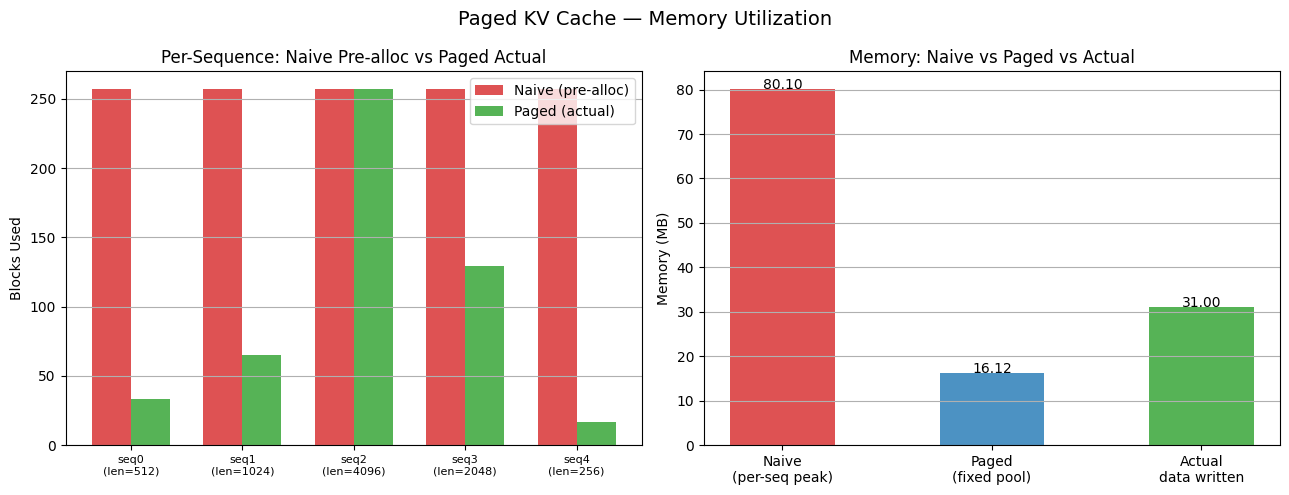

In [25]:
seq_ids      = [r[0] for r in seq_results]
out_lens     = [r[1] for r in seq_results]
blocks_used  = [r[3] for r in seq_results]

# Naive blocks needed = ceil(total_tokens / block_size)  per sequence
prompt_len = 5
block_size = 16

# Naive must pre-allocate max_total for EVERY sequence, not just the actual length
max_total = prompt_len + max(out_lens)   # = 5 + 4096 = 4101
naive_blocks_per_seq = math.ceil(max_total / block_size)  # = ceil(4101/16) = 257
naive_blocks = [naive_blocks_per_seq] * len(seq_ids)       # [257, 257, 257, 257, 257]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: per-sequence blocks used vs naive
x = range(len(seq_ids))
w = 0.35
axes[0].bar([i - w/2 for i in x], naive_blocks, width=w, label='Naive (pre-alloc)', color='tab:red',    alpha=0.8)
axes[0].bar([i + w/2 for i in x], blocks_used,  width=w, label='Paged (actual)',    color='tab:green',  alpha=0.8)
axes[0].set_xticks(list(x))
axes[0].set_xticklabels([f"seq{i}\n(len={l})" for i, l in zip(seq_ids, out_lens)], fontsize=8)
axes[0].set_ylabel('Blocks Used')
axes[0].set_title('Per-Sequence: Naive Pre-alloc vs Paged Actual')
axes[0].legend()
axes[0].grid(axis='y')

# Right: summary memory bar
labels_mem = ['Naive\n(per-seq peak)', 'Paged\n(fixed pool)', 'Actual\ndata written']
values_mem = [naive_mb, paged_mb, actual_mb]
colors     = ['tab:red', 'tab:blue', 'tab:green']
axes[1].bar(labels_mem, values_mem, color=colors, alpha=0.8, width=0.5)
axes[1].set_ylabel('Memory (MB)')
axes[1].set_title('Memory: Naive vs Paged vs Actual')
axes[1].grid(axis='y')
for i, v in enumerate(values_mem):
    axes[1].text(i, v + 0.05, f"{v:.2f}", ha='center', fontsize=10)

plt.suptitle('Paged KV Cache — Memory Utilization', fontsize=14)
plt.tight_layout()
plt.show()